In [41]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum, auto
import random

In [42]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2
class EnemyHealth(IntEnum): CRITICAL = 0; LOW = 1; MEDIUM = 2; HIGH = 3; FULL = 4

# State is the enemy's health discretized into 5 levels: CRITICAL, LOW, MEDIUM, HIGH, FULL
# Actions: Attack (damage enemy), Defend (protect team), Heal (support team)
# Transition depends on how many players attack vs enemy's random healing

# ROLE_ACTION_STATE_PROBS[role, enemy_health, action]
# Probabilities: P(action | role, enemy_health)
# Made LESS discriminative to slow convergence - roles are less "pure"
ROLE_ACTION_STATE_PROBS = np.array([
    # Fighter probabilities [enemy_health, action]
    [
        [0.60, 0.25, 0.15],  # CRITICAL: attack more (60% attack, 25% defend, 15% heal)
        [0.55, 0.30, 0.15],  # LOW: still attacking (55% attack)
        [0.50, 0.35, 0.15],  # MEDIUM: balanced attacker (50% attack)
        [0.50, 0.35, 0.15],  # HIGH: more cautious (50% attack)
        [0.45, 0.40, 0.15],  # FULL: most cautious (45% attack, 40% defend)
    ],
    # Tank probabilities [enemy_health, action]
    [
        [0.25, 0.60, 0.15],  # CRITICAL: still defend (60% defend)
        [0.25, 0.55, 0.20],  # LOW: defend (55% defend, 20% heal)
        [0.20, 0.55, 0.25],  # MEDIUM: balanced defender (55% defend)
        [0.15, 0.60, 0.25],  # HIGH: defend more (60% defend)
        [0.10, 0.65, 0.25],  # FULL: defend heavily (65% defend)
    ],
    # Healer probabilities [enemy_health, action]
    [
        [0.25, 0.15, 0.60],  # CRITICAL: support team (60% heal)
        [0.20, 0.20, 0.60],  # LOW: mostly heal (60% heal)
        [0.20, 0.20, 0.60],  # MEDIUM: heal (60% heal)
        [0.15, 0.20, 0.65],  # HIGH: heal more (65% heal)
        [0.10, 0.20, 0.70],  # FULL: heal heavily (70% heal)
    ],
])

@jax.jit
def role_policy(role, action, enemy_health):  # role-conditioned action likelihood P(action | role, enemy_health)
    return ROLE_ACTION_STATE_PROBS[role, enemy_health, action]

# Transition probability matrix [num_attackers, change_type]
# change_type: 0 = decrease health, 1 = stay same, 2 = increase health (enemy heals)
# REBALANCED: 1-2 attackers more effective, boss less regenerative
TRANSITION_PROBS = np.array([
    [0.0, 0.20, 0.80],   # 0 attackers: 80% heal (reduced from 85%)
    [0.35, 0.55, 0.10],  # 1 attacker: 35% damage! (buffed from 20%, heal nerfed from 30% to 10%)
    [0.55, 0.35, 0.10],  # 2 attackers: 55% damage (buffed from 45%)
    [0.75, 0.20, 0.05],  # 3 attackers: 75% damage (buffed from 70%)
])

@jax.jit
def Transition(current_enemy_health, num_attackers, key):
    """
    Update enemy health state based on number of attackers.
    
    Args:
        current_enemy_health: Current enemy health state (0=CRITICAL to 4=FULL)
        num_attackers: Number of players attacking (0-3)
        key: JAX random key for stochasticity
    
    Returns:
        next_enemy_health: Updated enemy health state
    
    Transition logic:
    - Boss is difficult but can be beaten with 1-2 attackers
    - More attackers -> higher chance enemy loses health
    - 1 attacker: 35% damage chance (viable for balanced teams)
    - 2+ attackers: Much more effective
    - Enemy can't go below CRITICAL or above FULL
    """
    
    # Clamp num_attackers to valid range
    num_attackers = np.clip(num_attackers, 0, 3)
    
    # Get probabilities based on number of attackers
    probs = TRANSITION_PROBS[num_attackers]
    
    # Sample the change (-1, 0, +1)
    change = jax.random.choice(key, np.array([-1, 0, 1]), p=probs)
    
    # Apply change with bounds
    next_health = np.clip(current_enemy_health + change, 0, 4)
    
    return next_health

# Player Stats System
# Each player has three stats: Strength (ATK), Defense (DEF), Support (SUP)
# Stats are normalized to sum to 1.0 for each player

def generate_player_stats(player_id, seed=42):
    """
    Generate random player stats.
    Each player has 3 stats that sum to 1.0: Strength, Defense, Support
    
    Args:
        player_id: ID of player (0, 1, or 2)
        seed: Random seed
    
    Returns:
        stats: [strength, defense, support] that sum to 1.0
    """
    random.seed(seed + player_id)
    # Sample from Dirichlet distribution for stats that sum to 1
    alpha = [1.0, 1.0, 1.0]  # Uniform prior over stats
    raw_stats = [random.gammavariate(a, 1.0) for a in alpha]
    total = sum(raw_stats)
    stats = [s / total for s in raw_stats]
    return np.array(stats)

def compute_role_utility(player_stats, role):
    """
    Compute utility of a role for a player based on their stats.
    
    Args:
        player_stats: [strength, defense, support]
        role: Role enum (Fighter=0, Tank=1, Healer=2)
    
    Returns:
        utility: How well-suited this player is for this role
    """
    # Role preferences:
    # Fighter: prefers high strength
    # Tank: prefers high defense
    # Healer: prefers high support
    if role == Role.Fighter:
        return player_stats[0]  # strength
    elif role == Role.Tank:
        return player_stats[1]  # defense
    else:  # Healer
        return player_stats[2]  # support

def create_utility_based_prior(player_stats_list, temperature=1.0, allow_duplicates=False):
    """
    Create role prior based on player stats.
    Higher utility for a role = higher prior probability.
    
    Args:
        player_stats_list: List of 3 player stat arrays [[str, def, sup], ...]
        temperature: Controls sharpness (lower = more deterministic)
        allow_duplicates: If True, allow multiple players to have the same role
    
    Returns:
        prior: 3x3x3 array of P(r0, r1, r2 | stats)
    """
    prior = np.zeros((3, 3, 3))
    
    for r0 in range(3):
        for r1 in range(3):
            for r2 in range(3):
                # Skip if roles are not unique (unless duplicates allowed)
                if not allow_duplicates:
                    if r0 == r1 or r0 == r2 or r1 == r2:
                        continue
                
                # Compute utility for each player in their assigned role
                u0 = compute_role_utility(player_stats_list[0], r0)
                u1 = compute_role_utility(player_stats_list[1], r1)
                u2 = compute_role_utility(player_stats_list[2], r2)
                
                # Total utility (multiplicative for simplicity)
                # Apply temperature: lower temp = sharper distribution
                utility = np.exp((u0 + u1 + u2) / temperature)
                prior = prior.at[r0, r1, r2].set(utility)
    
    # Normalize to get probability distribution
    prior = prior / np.sum(prior)
    
    return prior

@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]

In [43]:
@memo
def role_inference[r0 : Role, r1 : Role, r2 : Role](role_prior, obs_a0, obs_a1, obs_a2, enemy_health):
    observer: knows(r0, r1, r2) # Push array axis variables into observer's frame
    observer: thinks[
        team: assigned(r0 in Role, r1 in Role, r2 in Role, wpp=get_element(role_prior, r0, r1, r2)), # Assign roles to each player
        team: chooses(a0 in Action, wpp=role_policy(r0, a0, enemy_health)), # Choose player 0's action (a0) according to their role (r0)
        team: chooses(a1 in Action, wpp=role_policy(r1, a1, enemy_health)), # Choose player 1's action (a1) according to their role (r1)
        team: chooses(a2 in Action, wpp=role_policy(r2, a2, enemy_health))  # Choose player 2's action (a2) according to their role (r2)
    ]
    observer: observes_that [team.a0 == obs_a0] # Observe player 0's action
    observer: observes_that [team.a1 == obs_a1] # Observe player 1's action
    observer: observes_that [team.a2 == obs_a2] # Observe player 2's action
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]

# Generate player stats
stats_seed = 42  # Change to get different player compositions
player_stats = [generate_player_stats(i, seed=stats_seed) for i in range(3)]

print("="*60)
print("PLAYER STATS")
print("="*60)
for i, stats in enumerate(player_stats):
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")
    best_role_idx = int(np.argmax(stats))
    best_role = Role(best_role_idx).name
    print(f"  -> Best suited for: {best_role} (utility={stats[best_role_idx]:.2f})")
print("="*60)

# Create utility-based prior and show it
temperature = 2.0  # Higher temperature = more uncertainty
test_prior = create_utility_based_prior(player_stats, temperature=temperature)

print(f"\nUtility-Based Prior (temperature={temperature}):")
print("Top 5 most likely role assignments:")
# Flatten and sort to show top assignments
flat_indices = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if test_prior[r0, r1, r2] > 0:
                flat_indices.append(((r0, r1, r2), float(test_prior[r0, r1, r2])))

flat_indices.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_indices[:5]:
    print(f"  P0={Role(r0).name}, P1={Role(r1).name}, P2={Role(r2).name}: {prob:.3f}")
print()

# Run simple inference example
actions = [Action.Heal, Action.Defend, Action.Heal]
role_probs = role_inference(test_prior, *actions, enemy_health=EnemyHealth.MEDIUM, print_table=False)
print(f"After observing actions {[a.name for a in actions]} at MEDIUM enemy health:")
print("Top 3 inferred role assignments:")
flat_posterior = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if role_probs[r0, r1, r2] > 0:
                flat_posterior.append(((r0, r1, r2), float(role_probs[r0, r1, r2])))
flat_posterior.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_posterior[:3]:
    print(f"  P0={Role(r0).name}, P1={Role(r1).name}, P2={Role(r2).name}: {prob:.3f}")


PLAYER STATS
Player 0: STR=0.75, DEF=0.02, SUP=0.24
  -> Best suited for: Fighter (utility=0.75)
Player 1: STR=0.03, DEF=0.86, SUP=0.11
  -> Best suited for: Tank (utility=0.86)
Player 2: STR=0.16, DEF=0.24, SUP=0.60
  -> Best suited for: Healer (utility=0.60)

Utility-Based Prior (temperature=2.0):
Top 5 most likely role assignments:
  P0=Fighter, P1=Tank, P2=Healer: 0.289
  P0=Healer, P1=Tank, P2=Fighter: 0.179
  P0=Fighter, P1=Healer, P2=Tank: 0.166
  P0=Tank, P1=Fighter, P2=Healer: 0.132
  P0=Healer, P1=Fighter, P2=Tank: 0.123

After observing actions ['Heal', 'Defend', 'Heal'] at MEDIUM enemy health:
Top 3 inferred role assignments:
  P0=Fighter, P1=Tank, P2=Healer: 0.370
  P0=Healer, P1=Tank, P2=Fighter: 0.230
  P0=Tank, P1=Fighter, P2=Healer: 0.180


In [44]:
import random

def marginalize(role_probs, agent_idx):
    """Marginalize role probabilities to get distribution for a single agent."""
    if agent_idx == 0:
        return np.sum(role_probs, axis=(1, 2))
    elif agent_idx == 1:
        return np.sum(role_probs, axis=(0, 2))
    else:  # agent_idx == 2
        return np.sum(role_probs, axis=(0, 1))

def simulate_role_convergence(n_steps, player_stats_list, initial_enemy_health=EnemyHealth.FULL, 
                               seed=42, temperature=1.0):
    """
    Simulate the role coordination game with enemy health dynamics.
    Stops when enemy reaches CRITICAL health (death) or max steps reached.
    
    Args:
        n_steps: Maximum number of timesteps to simulate
        player_stats_list: List of 3 player stat arrays [[str, def, sup], ...]
        initial_enemy_health: Starting enemy health state
        seed: Random seed for reproducibility
        temperature: Temperature for utility-based prior (lower = sharper)
    
    Returns:
        role_history: History of sampled roles [actual_steps x 3]
        action_history: History of sampled actions [actual_steps x 3]
        role_prob_history: History of role beliefs [actual_steps x 3x3x3]
        enemy_health_history: History of enemy health states [actual_steps + 1] (includes final state)
        actual_steps: Actual number of action steps taken
        victory: Whether the enemy was defeated
        role_prior: Initial utility-based prior used
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Create utility-based prior from player stats
    role_prior = create_utility_based_prior(player_stats_list, temperature=temperature)
    role_probs = role_prior
    enemy_health = initial_enemy_health
    
    # Preallocate arrays for histories
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)  # +1 to store final state
    
    # Store initial enemy health
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    
    for t in range(n_steps):
        # Sample a role for each agent according to the marginal distribution over their role
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))  # Store roles

        # Sample an action for each agent according to the role policy conditioned on enemy health
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))  # Store actions

        # Update (common) beliefs about role assignments via role inference
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)  # Store updated probabilities
        
        # Count number of attackers (Action.Attack == 0)
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        
        # Update enemy health using Transition function
        key, subkey = jax.random.split(key)
        enemy_health = Transition(enemy_health, num_attackers, subkey)
        
        # Store new enemy health (at position t+1)
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        
        # Check if enemy is dead (CRITICAL = 0) AFTER the transition
        if enemy_health == EnemyHealth.CRITICAL:
            print(f"\n🎉 Victory! Enemy defeated at step {t + 1}!")
            actual_steps = t + 1
            victory = True
            break
    else:
        # Loop completed without break - enemy survived all steps
        actual_steps = n_steps
        victory = False
        print(f"\n💀 Defeat! Enemy survived {n_steps} steps with {EnemyHealth(enemy_health).name} health remaining.")

    # Trim arrays to actual length
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]  # +1 to include final state

    return role_history, action_history, role_prob_history, enemy_health_history, actual_steps, victory, role_prior



PLAYER STATS
Player 0: STR=0.42, DEF=0.02, SUP=0.57
  -> Best suited for: Healer (utility=0.57)
Player 1: STR=0.17, DEF=0.74, SUP=0.09
  -> Best suited for: Tank (utility=0.74)
Player 2: STR=0.29, DEF=0.57, SUP=0.14
  -> Best suited for: Tank (utility=0.57)

🎉 Victory! Enemy defeated at step 41!

Simulation ran for 41 action steps

Simulation History (First 10 Steps):
Timestep   | Enemy HP   | Player 0        | Player 1        | Player 2       
-------------------------------------------------------------------------------------
Step 1     | FULL       | Fighter         | Fighter         | Tank           
           |            | Attack          | Attack          | Defend         
Step 2     | FULL       | Healer          | Tank            | Tank           
           |            | Heal            | Heal            | Heal           
Step 3     | FULL       | Fighter         | Healer          | Tank           
           |            | Defend          | Heal            | Defend      

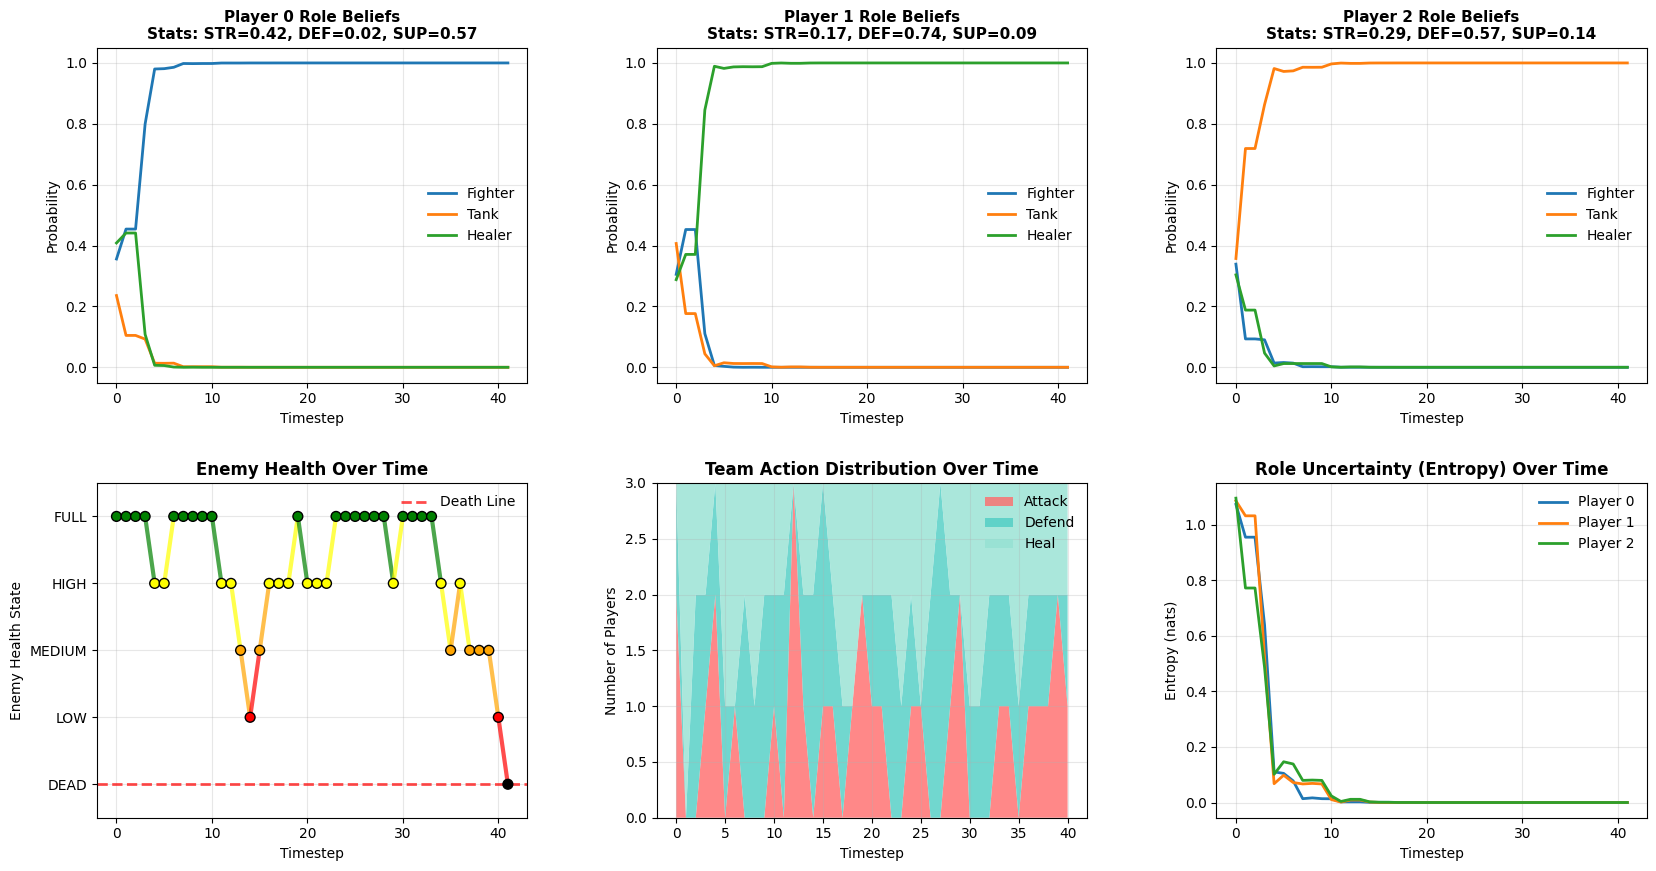


FINAL STATISTICS
Battle Duration: 41 action steps
Final Enemy Health: CRITICAL
Result: 🎉 VICTORY! 🎉

Final role assignment (most likely):
  Player 0: Fighter
  Player 1: Healer
  Player 2: Tank

Action Distribution:
  Attacks: 31/123 (25.2%)
  Defends: 44/123 (35.8%)
  Heals: 48/123 (39.0%)

Coordination Analysis:
  Players in non-optimal roles: 2/3
    Player 0: Best for Healer, ended up as Fighter
    Player 1: Best for Tank, ended up as Healer


In [45]:
# Run simulation
import time

max_steps = 100
temperature = 2.0  # Higher = more uncertainty in role prior

# Use current time for random seed - different every run!
seed = int(time.time() * 1000) % 100000

# Generate player stats
player_stats = [generate_player_stats(i, seed=seed) for i in range(3)]

print("\n" + "="*60)
print("PLAYER STATS")
print("="*60)
for i, stats in enumerate(player_stats):
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")
    best_role_idx = int(np.argmax(stats))
    best_role = Role(best_role_idx).name
    print(f"  -> Best suited for: {best_role} (utility={stats[best_role_idx]:.2f})")
print("="*60)

role_history, action_history, role_prob_history, enemy_health_history, n_steps, victory, role_prior = simulate_role_convergence(
    max_steps, player_stats, initial_enemy_health=EnemyHealth.FULL, seed=seed, temperature=temperature
)

print(f"\nSimulation ran for {n_steps} action steps")
print("\nSimulation History (First 10 Steps):")
print(f"{'Timestep':<10} | {'Enemy HP':<10} | {'Player 0':<15} | {'Player 1':<15} | {'Player 2':<15}")
print("-" * 85)

for t in range(min(10, n_steps)):
    roles = [Role(r).name for r in role_history[t]]
    actions = [Action(a).name for a in action_history[t]]
    enemy_hp = EnemyHealth(int(enemy_health_history[t])).name
    print(f"{f'Step {t+1}':<10} | {enemy_hp:<10} | {roles[0]:<15} | {roles[1]:<15} | {roles[2]:<15}")
    print(f"{'':<10} | {'':<10} | {actions[0]:<15} | {actions[1]:<15} | {actions[2]:<15}")

import matplotlib.pyplot as plt
import numpy as onp  # Use original numpy for non-JAX operations

# Create a figure with 4 subplots: 3 for role probabilities + 1 for enemy health
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Top row: Role probability evolution for each player
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    
    # Calculate marginal probabilities for the current player at each timestep
    player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
    # Add the initial timestep's probabilities
    player_role_probs.insert(0, marginalize(role_prior / role_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)

    # Plot the evolution of role probabilities for the current player
    for role in Role:
        ax.plot(range(n_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)

    # Add player stats to title
    stats = player_stats[i]
    title = f'Player {i} Role Beliefs\nStats: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Bottom left: Enemy health over time
ax_health = fig.add_subplot(gs[1, 0])
health_names = ['DEAD', 'LOW', 'MEDIUM', 'HIGH', 'FULL']
health_colors = ['black', 'red', 'orange', 'yellow', 'green']
enemy_health_arr = onp.array(enemy_health_history)

# Plot with color coding
for i in range(len(enemy_health_arr) - 1):
    color = health_colors[int(enemy_health_arr[i])]
    ax_health.plot([i, i+1], [enemy_health_arr[i], enemy_health_arr[i+1]], 
                   color=color, linewidth=3, alpha=0.7)
    
ax_health.scatter(range(len(enemy_health_arr)), enemy_health_arr, 
                 c=[health_colors[int(h)] for h in enemy_health_arr], 
                 s=50, zorder=3, edgecolors='black', linewidth=1)
ax_health.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Death Line', alpha=0.7)
ax_health.set_title('Enemy Health Over Time', fontsize=12, fontweight='bold')
ax_health.set_xlabel('Timestep')
ax_health.set_ylabel('Enemy Health State')
ax_health.set_yticks(range(5))
ax_health.set_yticklabels(health_names)
ax_health.legend(frameon=False)
ax_health.grid(True, alpha=0.3)
ax_health.set_ylim([-0.5, 4.5])

# Bottom middle: Action distribution over time
ax_actions = fig.add_subplot(gs[1, 1])
action_counts = onp.zeros((n_steps, 3))
for t in range(n_steps):
    for a in action_history[t]:
        action_counts[t, int(a)] += 1

ax_actions.stackplot(range(n_steps), 
                     action_counts[:, 0], action_counts[:, 1], action_counts[:, 2],
                     labels=['Attack', 'Defend', 'Heal'],
                     colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
                     alpha=0.8)
ax_actions.set_title('Team Action Distribution Over Time', fontsize=12, fontweight='bold')
ax_actions.set_xlabel('Timestep')
ax_actions.set_ylabel('Number of Players')
ax_actions.legend(loc='upper right', frameon=False)
ax_actions.grid(True, alpha=0.3)
ax_actions.set_ylim([0, 3])

# Bottom right: Role entropy over time (measure of role uncertainty)
ax_entropy = fig.add_subplot(gs[1, 2])
from scipy.stats import entropy

role_entropy = onp.zeros((n_steps + 1, 3))
for i in range(3):
    # Initial entropy
    initial_marginal = marginalize(role_prior / role_prior.sum(), i)
    role_entropy[0, i] = entropy(onp.array(initial_marginal))
    
    # Entropy over time
    for t in range(n_steps):
        marginal = marginalize(role_prob_history[t], i)
        role_entropy[t + 1, i] = entropy(onp.array(marginal))

for i in range(3):
    ax_entropy.plot(range(n_steps + 1), role_entropy[:, i], label=f'Player {i}', linewidth=2)

ax_entropy.set_title('Role Uncertainty (Entropy) Over Time', fontsize=12, fontweight='bold')
ax_entropy.set_xlabel('Timestep')
ax_entropy.set_ylabel('Entropy (nats)')
ax_entropy.legend(frameon=False)
ax_entropy.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print("\n" + "="*60)
print("FINAL STATISTICS")
print("="*60)
final_enemy_health = int(enemy_health_history[-1])
print(f"Battle Duration: {n_steps} action steps")
print(f"Final Enemy Health: {EnemyHealth(final_enemy_health).name}")
print(f"Result: {'🎉 VICTORY! 🎉' if victory else '💀 DEFEAT 💀'}")

if n_steps > 0:
    final_roles = [Role(onp.argmax(onp.array(marginalize(role_prob_history[-1], i)))).name for i in range(3)]
    print(f"\nFinal role assignment (most likely):")
    print(f"  Player 0: {final_roles[0]}")
    print(f"  Player 1: {final_roles[1]}")
    print(f"  Player 2: {final_roles[2]}")
    
    # Calculate average action distribution
    total_attacks = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Attack])
    total_defends = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Defend])
    total_heals = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Heal])
    total_actions = total_attacks + total_defends + total_heals
    
    print(f"\nAction Distribution:")
    print(f"  Attacks: {total_attacks}/{total_actions} ({100*total_attacks/total_actions:.1f}%)")
    print(f"  Defends: {total_defends}/{total_actions} ({100*total_defends/total_actions:.1f}%)")
    print(f"  Heals: {total_heals}/{total_actions} ({100*total_heals/total_actions:.1f}%)")
    
    # Show coordination challenges
    print(f"\nCoordination Analysis:")
    best_roles = [Role(onp.argmax(player_stats[i])).name for i in range(3)]
    actual_roles = final_roles
    mismatches = sum(1 for i in range(3) if best_roles[i] != actual_roles[i])
    print(f"  Players in non-optimal roles: {mismatches}/3")
    for i in range(3):
        if best_roles[i] != actual_roles[i]:
            print(f"    Player {i}: Best for {best_roles[i]}, ended up as {actual_roles[i]}")
print("="*60)


In [46]:
# DIAGNOSTIC ANALYSIS: Why did a high-STR player become Tank instead of Fighter?
# Run this cell after the main simulation to understand role convergence

import numpy as onp

print("\n" + "="*80)
print("DIAGNOSTIC ANALYSIS: Understanding Role Convergence")
print("="*80)

# 1. Initial Prior Analysis
print("\n1. INITIAL UTILITY-BASED PRIOR:")
print("-" * 80)
print("Player 0's marginal probabilities at t=0:")
initial_p0_marginal = marginalize(role_prior / role_prior.sum(), 0)
for role_idx, prob in enumerate(initial_p0_marginal):
    role_name = Role(role_idx).name
    utility = player_stats[0][role_idx]
    print(f"  P(Player 0 = {role_name:7s}) = {prob:.3f}  (utility={utility:.2f})")

print("\nTop 3 joint role assignments initially:")
flat_prior = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if role_prior[r0, r1, r2] > 0:
                flat_prior.append(((r0, r1, r2), float(role_prior[r0, r1, r2])))
flat_prior.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_prior[:3]:
    print(f"  P0={Role(r0).name:7s}, P1={Role(r1).name:7s}, P2={Role(r2).name:7s}: {prob:.3f}")

# 2. Early Convergence Analysis
print("\n2. EARLY ACTIONS AND BELIEF UPDATES (first 10 steps):")
print("-" * 80)
for t in range(min(10, n_steps)):
    actions = [Action(int(a)).name for a in action_history[t]]
    p0_beliefs = marginalize(role_prob_history[t], 0)

    print(f"\nStep {t+1}:")
    print(f"  Actions: P0={actions[0]:7s}, P1={actions[1]:7s}, P2={actions[2]:7s}")
    print(f"  Player 0 beliefs after observation:")
    for role_idx, prob in enumerate(p0_beliefs):
        print(f"    P(P0={Role(role_idx).name:7s}) = {prob:.3f}")

# 3. Likelihood Analysis
print("\n3. LIKELIHOOD ANALYSIS:")
print("-" * 80)
print("Why certain actions favor certain role assignments:")
print("\nAction likelihoods P(action | role) at FULL enemy health:")
for role in Role:
    probs = ROLE_ACTION_STATE_PROBS[role, EnemyHealth.FULL, :]
    print(f"  {role.name:7s}: Attack={probs[0]:.2f}, Defend={probs[1]:.2f}, Heal={probs[2]:.2f}")

# 4. Find the critical step where Player 0 switched roles
print("\n4. ROLE CONVERGENCE TRAJECTORY:")
print("-" * 80)
p0_fighter_probs = [marginalize(role_prob_history[t], 0)[Role.Fighter] for t in range(n_steps)]
p0_tank_probs = [marginalize(role_prob_history[t], 0)[Role.Tank] for t in range(n_steps)]
p0_healer_probs = [marginalize(role_prob_history[t], 0)[Role.Healer] for t in range(n_steps)]

# Find when Tank overtook Fighter (if it did)
crossover_step = None
for t in range(len(p0_tank_probs)):
    if p0_tank_probs[t] > p0_fighter_probs[t]:
        crossover_step = t
        break

if crossover_step is not None and crossover_step > 0:
    print(f"Player 0 belief shifted to Tank at step {crossover_step + 1}")
    print(f"\nAt step {crossover_step}:")
    print(f"  P(P0=Fighter) = {p0_fighter_probs[crossover_step-1]:.3f}")
    print(f"  P(P0=Tank)    = {p0_tank_probs[crossover_step-1]:.3f}")
    print(f"\nAt step {crossover_step + 1}:")
    print(f"  P(P0=Fighter) = {p0_fighter_probs[crossover_step]:.3f}")
    print(f"  P(P0=Tank)    = {p0_tank_probs[crossover_step]:.3f}")

    # Show what happened at that step
    if crossover_step < n_steps:
        actions_at_crossover = [Action(int(a)).name for a in action_history[crossover_step]]
        print(f"\n  Actions observed: P0={actions_at_crossover[0]}, P1={actions_at_crossover[1]}, P2={actions_at_crossover[2]}")
elif crossover_step == 0:
    print("Player 0 started as Tank from step 1")
else:
    print("Player 0 remained as Fighter throughout the simulation")

# 5. Key Insight
print("\n5. KEY INSIGHTS:")
print("-" * 80)
print("Why a high-STR player might become Tank instead of Fighter:")
print()
print("a) PRIOR INFLUENCE:")
print("   Even with high STR, the temperature=2.0 allows significant probability")
print("   mass on non-optimal roles. Prior doesn't completely determine roles.")
print()
print("b) BAYESIAN UPDATING:")
print("   Posterior: P(role | actions) ∝ P(actions | role) × P(role)")
print("   If Player 0 Defends early (which both Fighter and Tank do at 40% and 65%),")
print("   and if (P0=Tank, P1=Fighter, P2=Healer) explains observations better")
print("   than (P0=Fighter, P1=Tank, P2=Healer), beliefs shift to Tank.")
print()
print("c) JOINT INFERENCE WITH UNIQUENESS CONSTRAINT:")
print("   Roles must be unique! If Player 1's actions strongly suggest Fighter,")
print("   then Player 0 cannot be Fighter, even with high STR.")
print("   The system coordinates roles based on observed behavior, not just stats.")
print()

# 6. Check if another player "claimed" the Fighter role
print("6. FINAL ROLE DISTRIBUTION:")
print("-" * 80)
final_marginals = [marginalize(role_prob_history[-1], i) for i in range(3)]
for i in range(3):
    best_role = Role(onp.argmax(final_marginals[i])).name
    best_stat = Role(onp.argmax(player_stats[i])).name
    fighter_prob = final_marginals[i][Role.Fighter]
    tank_prob = final_marginals[i][Role.Tank]
    healer_prob = final_marginals[i][Role.Healer]
    print(f"Player {i}:")
    print(f"  Best stat role = {best_stat}, Final role = {best_role}")
    print(f"  P(Fighter)={fighter_prob:.3f}, P(Tank)={tank_prob:.3f}, P(Healer)={healer_prob:.3f}")

print("\n" + "="*80)



DIAGNOSTIC ANALYSIS: Understanding Role Convergence

1. INITIAL UTILITY-BASED PRIOR:
--------------------------------------------------------------------------------
Player 0's marginal probabilities at t=0:
  P(Player 0 = Fighter) = 0.356  (utility=0.42)
  P(Player 0 = Tank   ) = 0.236  (utility=0.02)
  P(Player 0 = Healer ) = 0.408  (utility=0.57)

Top 3 joint role assignments initially:
  P0=Healer , P1=Tank   , P2=Fighter: 0.219
  P0=Healer , P1=Fighter, P2=Tank   : 0.189
  P0=Fighter, P1=Tank   , P2=Healer : 0.188

2. EARLY ACTIONS AND BELIEF UPDATES (first 10 steps):
--------------------------------------------------------------------------------

Step 1:
  Actions: P0=Attack , P1=Attack , P2=Defend 
  Player 0 beliefs after observation:
    P(P0=Fighter) = 0.454
    P(P0=Tank   ) = 0.105
    P(P0=Healer ) = 0.441

Step 2:
  Actions: P0=Heal   , P1=Heal   , P2=Heal   
  Player 0 beliefs after observation:
    P(P0=Fighter) = 0.454
    P(P0=Tank   ) = 0.105
    P(P0=Healer ) = 0.

In [47]:
# COMPARISON: Unique vs Non-Unique Roles
print("=" * 80)
print("COMPARING UNIQUE VS NON-UNIQUE ROLE CONSTRAINTS")
print("=" * 80)

# Use the same player stats for fair comparison
test_stats = [generate_player_stats(i, seed=42) for i in range(3)]

print("\nPlayer Stats:")
for i, stats in enumerate(test_stats):
    print(f"  Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")

# Create both priors
unique_prior = create_utility_based_prior(test_stats, temperature=2.0, allow_duplicates=False)
nonunique_prior = create_utility_based_prior(test_stats, temperature=2.0, allow_duplicates=True)

print("\n" + "-" * 80)
print("UNIQUE ROLES (Original)")
print("-" * 80)
print("Top 5 most likely role assignments:")
flat_unique = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if unique_prior[r0, r1, r2] > 0:
                flat_unique.append(((r0, r1, r2), float(unique_prior[r0, r1, r2])))
flat_unique.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_unique[:5]:
    print(f"  P0={Role(r0).name:7s}, P1={Role(r1).name:7s}, P2={Role(r2).name:7s}: {prob:.3f}")

print("\n" + "-" * 80)
print("NON-UNIQUE ROLES (Duplicates Allowed)")
print("-" * 80)
print("Top 10 most likely role assignments:")
flat_nonunique = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if nonunique_prior[r0, r1, r2] > 0:
                flat_nonunique.append(((r0, r1, r2), float(nonunique_prior[r0, r1, r2])))
flat_nonunique.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_nonunique[:10]:
    duplicate_marker = " [DUPLICATE]" if (r0 == r1 or r0 == r2 or r1 == r2) else ""
    print(f"  P0={Role(r0).name:7s}, P1={Role(r1).name:7s}, P2={Role(r2).name:7s}: {prob:.3f}{duplicate_marker}")

# Test inference with same observation
print("\n" + "-" * 80)
print("INFERENCE TEST: Observing [Attack, Attack, Defend] at FULL health")
print("-" * 80)

test_actions = [Action.Attack, Action.Attack, Action.Defend]

# Run inference with both priors
unique_posterior = role_inference(unique_prior, *test_actions, enemy_health=EnemyHealth.FULL)
nonunique_posterior = role_inference(nonunique_prior, *test_actions, enemy_health=EnemyHealth.FULL)

print("\nUnique Roles - Top 3 posterior assignments:")
flat_unique_post = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if unique_posterior[r0, r1, r2] > 0:
                flat_unique_post.append(((r0, r1, r2), float(unique_posterior[r0, r1, r2])))
flat_unique_post.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_unique_post[:3]:
    print(f"  P0={Role(r0).name:7s}, P1={Role(r1).name:7s}, P2={Role(r2).name:7s}: {prob:.3f}")

print("\nNon-Unique Roles - Top 5 posterior assignments:")
flat_nonunique_post = []
for r0 in range(3):
    for r1 in range(3):
        for r2 in range(3):
            if nonunique_posterior[r0, r1, r2] > 0:
                flat_nonunique_post.append(((r0, r1, r2), float(nonunique_posterior[r0, r1, r2])))
flat_nonunique_post.sort(key=lambda x: x[1], reverse=True)
for (r0, r1, r2), prob in flat_nonunique_post[:5]:
    duplicate_marker = " [DUPLICATE]" if (r0 == r1 or r0 == r2 or r1 == r2) else ""
    print(f"  P0={Role(r0).name:7s}, P1={Role(r1).name:7s}, P2={Role(r2).name:7s}: {prob:.3f}{duplicate_marker}")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)
print("\n1. With UNIQUE roles:")
print("   - Only 6 possible configurations (3! = 6 permutations)")
print("   - Forces role diversity across the team")
print("   - Players coordinate to fill different niches")
print("\n2. With NON-UNIQUE roles:")
print(f"   - All 27 possible configurations (3^3 = 27)")
print("   - Players can converge to the same role")
print("   - If all have high STR, all might become Fighters")
print("   - Team composition may be suboptimal (e.g., 3 Healers, 0 Fighters)")
print("\n3. Game Impact:")
print("   - Non-unique allows 'natural' convergence based on stats alone")
print("   - But may lead to poor team balance and defeat")
print("   - Unique constraint enforces complementarity")
print("=" * 80)

COMPARING UNIQUE VS NON-UNIQUE ROLE CONSTRAINTS

Player Stats:
  Player 0: STR=0.75, DEF=0.02, SUP=0.24
  Player 1: STR=0.03, DEF=0.86, SUP=0.11
  Player 2: STR=0.16, DEF=0.24, SUP=0.60

--------------------------------------------------------------------------------
UNIQUE ROLES (Original)
--------------------------------------------------------------------------------
Top 5 most likely role assignments:
  P0=Fighter, P1=Tank   , P2=Healer : 0.289
  P0=Healer , P1=Tank   , P2=Fighter: 0.179
  P0=Fighter, P1=Healer , P2=Tank   : 0.166
  P0=Tank   , P1=Fighter, P2=Healer : 0.132
  P0=Healer , P1=Fighter, P2=Tank   : 0.123

--------------------------------------------------------------------------------
NON-UNIQUE ROLES (Duplicates Allowed)
--------------------------------------------------------------------------------
Top 10 most likely role assignments:
  P0=Fighter, P1=Tank   , P2=Healer : 0.065
  P0=Fighter, P1=Tank   , P2=Tank   : 0.055 [DUPLICATE]
  P0=Fighter, P1=Tank   , P2=Figh


SIMULATION COMPARISON: Unique vs Non-Unique Roles

Player Stats:
  Player 0: STR=0.75, DEF=0.02, SUP=0.24
  Player 1: STR=0.03, DEF=0.86, SUP=0.11
  Player 2: STR=0.16, DEF=0.24, SUP=0.60

--------------------------------------------------------------------------------
Running UNIQUE ROLES simulation...
--------------------------------------------------------------------------------
Result: VICTORY in 9 steps

--------------------------------------------------------------------------------
Running NON-UNIQUE ROLES simulation...
--------------------------------------------------------------------------------
Result: VICTORY in 8 steps


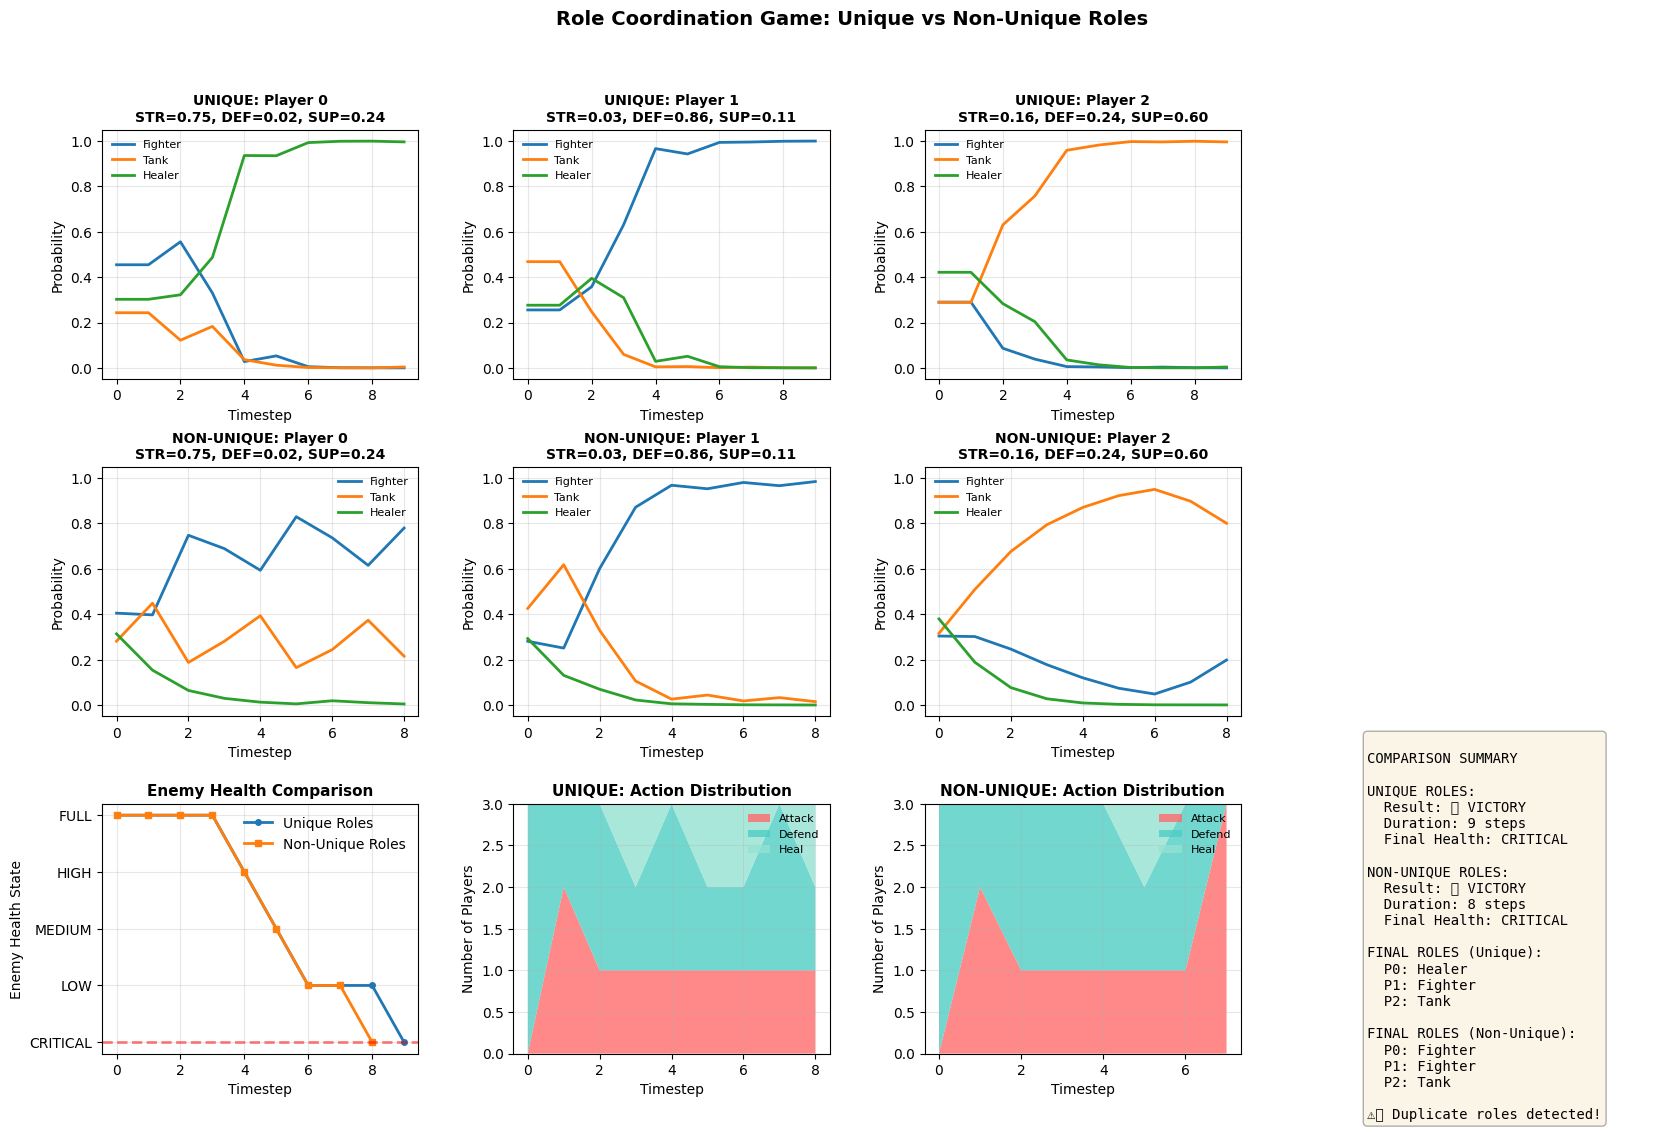

In [48]:
# SIDE-BY-SIDE SIMULATION: Unique vs Non-Unique Roles
import matplotlib.pyplot as plt
import numpy as onp

print("\n" + "=" * 80)
print("SIMULATION COMPARISON: Unique vs Non-Unique Roles")
print("=" * 80)

# Use same player stats and seed for both
comparison_seed = 42
comparison_stats = [generate_player_stats(i, seed=comparison_seed) for i in range(3)]

print("\nPlayer Stats:")
for i, stats in enumerate(comparison_stats):
    print(f"  Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")

# Modify simulate_role_convergence to accept allow_duplicates parameter
def simulate_with_constraint(n_steps, player_stats_list, allow_duplicates, initial_enemy_health=EnemyHealth.FULL, 
                              seed=42, temperature=1.0):
    """Simulation with configurable role uniqueness constraint."""
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Create prior with or without uniqueness
    role_prior = create_utility_based_prior(player_stats_list, temperature=temperature, allow_duplicates=allow_duplicates)
    role_probs = role_prior
    enemy_health = initial_enemy_health
    
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    
    for t in range(n_steps):
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))
        
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))
        
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)
        
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        
        key, subkey = jax.random.split(key)
        enemy_health = Transition(enemy_health, num_attackers, subkey)
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        
        if enemy_health == EnemyHealth.CRITICAL:
            actual_steps = t + 1
            victory = True
            break
    else:
        actual_steps = n_steps
        victory = False
    
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]
    
    return role_history, action_history, role_prob_history, enemy_health_history, actual_steps, victory, role_prior

# Run both simulations
max_steps = 100
temp = 2.0

print("\n" + "-" * 80)
print("Running UNIQUE ROLES simulation...")
print("-" * 80)
unique_results = simulate_with_constraint(max_steps, comparison_stats, allow_duplicates=False, 
                                          seed=comparison_seed, temperature=temp)
unique_history, unique_actions, unique_probs, unique_health, unique_steps, unique_victory, unique_prior = unique_results
print(f"Result: {'VICTORY' if unique_victory else 'DEFEAT'} in {unique_steps} steps")

print("\n" + "-" * 80)
print("Running NON-UNIQUE ROLES simulation...")
print("-" * 80)
nonunique_results = simulate_with_constraint(max_steps, comparison_stats, allow_duplicates=True, 
                                             seed=comparison_seed, temperature=temp)
nonunique_history, nonunique_actions, nonunique_probs, nonunique_health, nonunique_steps, nonunique_victory, nonunique_prior = nonunique_results
print(f"Result: {'VICTORY' if nonunique_victory else 'DEFEAT'} in {nonunique_steps} steps")

# Create comparison visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Row 1: Role probabilities for UNIQUE constraint
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    player_role_probs = [marginalize(unique_probs[t], i) for t in range(unique_steps)]
    player_role_probs.insert(0, marginalize(unique_prior / unique_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)
    
    for role in Role:
        ax.plot(range(unique_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)
    
    stats = comparison_stats[i]
    ax.set_title(f'UNIQUE: Player {i}\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}', 
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 2: Role probabilities for NON-UNIQUE constraint
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    player_role_probs = [marginalize(nonunique_probs[t], i) for t in range(nonunique_steps)]
    player_role_probs.insert(0, marginalize(nonunique_prior / nonunique_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)
    
    for role in Role:
        ax.plot(range(nonunique_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)
    
    stats = comparison_stats[i]
    ax.set_title(f'NON-UNIQUE: Player {i}\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}', 
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 3, Col 1: Enemy health comparison
ax = fig.add_subplot(gs[2, 0])
ax.plot(range(len(unique_health)), unique_health, label='Unique Roles', linewidth=2, marker='o', markersize=4)
ax.plot(range(len(nonunique_health)), nonunique_health, label='Non-Unique Roles', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.set_title('Enemy Health Comparison', fontsize=11, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Enemy Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRITICAL', 'LOW', 'MEDIUM', 'HIGH', 'FULL'])
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# Row 3, Col 2: Action distribution comparison - UNIQUE
ax = fig.add_subplot(gs[2, 1])
action_counts_unique = onp.zeros((unique_steps, 3))
for t in range(unique_steps):
    for a in unique_actions[t]:
        action_counts_unique[t, int(a)] += 1
ax.stackplot(range(unique_steps), 
            action_counts_unique[:, 0], action_counts_unique[:, 1], action_counts_unique[:, 2],
            labels=['Attack', 'Defend', 'Heal'],
            colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
            alpha=0.8)
ax.set_title('UNIQUE: Action Distribution', fontsize=11, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Number of Players')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 3])

# Row 3, Col 3: Action distribution comparison - NON-UNIQUE
ax = fig.add_subplot(gs[2, 2])
action_counts_nonunique = onp.zeros((nonunique_steps, 3))
for t in range(nonunique_steps):
    for a in nonunique_actions[t]:
        action_counts_nonunique[t, int(a)] += 1
ax.stackplot(range(nonunique_steps), 
            action_counts_nonunique[:, 0], action_counts_nonunique[:, 1], action_counts_nonunique[:, 2],
            labels=['Attack', 'Defend', 'Heal'],
            colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
            alpha=0.8)
ax.set_title('NON-UNIQUE: Action Distribution', fontsize=11, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Number of Players')
ax.legend(loc='upper right', frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 3])

# Row 3, Col 4: Summary statistics
ax = fig.add_subplot(gs[2, 3])
ax.axis('off')

summary_text = f"""
COMPARISON SUMMARY

UNIQUE ROLES:
  Result: {'🎉 VICTORY' if unique_victory else '💀 DEFEAT'}
  Duration: {unique_steps} steps
  Final Health: {EnemyHealth(int(unique_health[-1])).name}
  
NON-UNIQUE ROLES:
  Result: {'🎉 VICTORY' if nonunique_victory else '💀 DEFEAT'}
  Duration: {nonunique_steps} steps
  Final Health: {EnemyHealth(int(nonunique_health[-1])).name}

FINAL ROLES (Unique):
"""
unique_final = [Role(onp.argmax(onp.array(marginalize(unique_probs[-1], i)))).name for i in range(3)]
for i in range(3):
    summary_text += f"  P{i}: {unique_final[i]}\n"

summary_text += f"\nFINAL ROLES (Non-Unique):\n"
nonunique_final = [Role(onp.argmax(onp.array(marginalize(nonunique_probs[-1], i)))).name for i in range(3)]
for i in range(3):
    summary_text += f"  P{i}: {nonunique_final[i]}\n"

# Check for duplicates
nonunique_has_dups = len(nonunique_final) != len(set(nonunique_final))
if nonunique_has_dups:
    summary_text += "\n⚠️ Duplicate roles detected!"

ax.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Role Coordination Game: Unique vs Non-Unique Roles', 
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

In [49]:
# ============================================================================
# ENHANCED COMBAT SYSTEM: Two-Sided Battle with Team Health
# ============================================================================

print("=" * 80)
print("ENHANCED COMBAT SYSTEM WITH TEAM HEALTH")
print("=" * 80)

# Add TeamHealth state
class TeamHealth(IntEnum): 
    CRITICAL = 0  # Near death
    LOW = 1       # Damaged
    MEDIUM = 2    # Slightly hurt
    HIGH = 3      # Almost full
    FULL = 4      # Perfect health

# ENEMY ATTACK PROBABILITIES (REBALANCED - More threatening)
# Probability that enemy attacks (vs does nothing) depends on enemy health
# Healthier enemy = more aggressive
ENEMY_ATTACK_PROB = np.array([
    0.25,  # CRITICAL: 25% attack (very weak)
    0.40,  # LOW: 40% attack
    0.55,  # MEDIUM: 55% attack (buffed from 40%)
    0.65,  # HIGH: 65% attack (buffed from 50%)
    0.75,  # FULL: 75% attack (buffed from 50% - much more aggressive!)
])

# TEAM DAMAGE TRANSITION [num_defenders, damage_type]
# damage_type: 0 = lose health, 1 = stay same, 2 = gain health
# More defenders = better protection (SLIGHTLY NERFED - Defense is less perfect)
TEAM_DAMAGE_PROBS = np.array([
    [0.70, 0.25, 0.05],  # 0 defenders: 70% take damage (nerfed from 60%)
    [0.45, 0.40, 0.15],  # 1 defender: 45% take damage (nerfed from 35%)
    [0.25, 0.55, 0.20],  # 2 defenders: 25% take damage (nerfed from 15%)
    [0.10, 0.65, 0.25],  # 3 defenders: 10% take damage (nerfed from 5%)
])

# TEAM HEAL TRANSITION [num_healers, heal_type]
# heal_type: 0 = lose health, 1 = stay same, 2 = gain health
# More healers = better healing (SAME - healing is important)
TEAM_HEAL_PROBS = np.array([
    [0.0, 0.85, 0.15],   # 0 healers: 15% natural regen
    [0.0, 0.30, 0.70],   # 1 healer: 70% gain health
    [0.0, 0.15, 0.85],   # 2 healers: 85% gain health
    [0.0, 0.05, 0.95],   # 3 healers: 95% gain health
])

@jax.jit
def UpdateTeamHealth(current_team_health, enemy_health, num_defenders, num_healers, key):
    """
    Update team health based on enemy attack, defenders, and healers.
    
    Args:
        current_team_health: Current team health state (0=CRITICAL to 4=FULL)
        enemy_health: Current enemy health state (affects attack probability)
        num_defenders: Number of players defending (0-3)
        num_healers: Number of players healing (0-3)
        key: JAX random key
    
    Returns:
        next_team_health: Updated team health state
    
    Logic:
    1. Enemy attacks with probability based on enemy_health
    2. If attacked: damage depends on num_defenders
    3. Regardless: healing depends on num_healers
    4. Final health = current + damage_change + heal_change
    """
    
    key1, key2, key3 = jax.random.split(key, 3)
    
    # Clamp inputs
    num_defenders = np.clip(num_defenders, 0, 3)
    num_healers = np.clip(num_healers, 0, 3)
    
    # Step 1: Does enemy attack?
    enemy_attacks = jax.random.uniform(key1) < ENEMY_ATTACK_PROB[enemy_health]
    
    # Step 2: If attacked, calculate damage
    damage_change = jax.lax.cond(
        enemy_attacks,
        lambda: jax.random.choice(key2, np.array([-1, 0, 1]), p=TEAM_DAMAGE_PROBS[num_defenders]),
        lambda: 0  # No attack = no damage
    )
    
    # Step 3: Calculate healing (happens regardless of attack)
    heal_change = jax.random.choice(key3, np.array([-1, 0, 1]), p=TEAM_HEAL_PROBS[num_healers])
    
    # Step 4: Apply both changes
    total_change = damage_change + heal_change
    next_health = np.clip(current_team_health + total_change, 0, 4)
    
    return next_health

@jax.jit
def UpdateEnemyHealth(current_enemy_health, num_attackers, key):
    """
    Update enemy health based on number of attackers.
    (Same as before, but renamed for clarity)
    """
    num_attackers = np.clip(num_attackers, 0, 3)
    probs = TRANSITION_PROBS[num_attackers]
    change = jax.random.choice(key, np.array([-1, 0, 1]), p=probs)
    next_health = np.clip(current_enemy_health + change, 0, 4)
    return next_health

print("\n✅ Enhanced combat system defined!")
print("\nKey Mechanics (REBALANCED V2):")
print("  - Enemy attacks: 25%-75% based on health (increased aggression!)")
print("  - Defenders: 0 def: 70% damage → 3 def: 10% damage (slightly nerfed)")
print("  - Healers: 0 heal: 15% regen → 3 heal: 95% heal (unchanged)")
print("  - Boss damage buffed: 1 attacker now 35% effective (was 20%)")
print("  - More dangerous but beatable with coordination!")
print("=" * 80)

ENHANCED COMBAT SYSTEM WITH TEAM HEALTH

✅ Enhanced combat system defined!

Key Mechanics (REBALANCED V2):
  - Enemy attacks: 25%-75% based on health (increased aggression!)
  - Defenders: 0 def: 70% damage → 3 def: 10% damage (slightly nerfed)
  - Healers: 0 heal: 15% regen → 3 heal: 95% heal (unchanged)
  - Boss damage buffed: 1 attacker now 35% effective (was 20%)
  - More dangerous but beatable with coordination!


In [50]:
# ============================================================================
# ENHANCED SIMULATION WITH TWO-SIDED COMBAT
# ============================================================================

def simulate_enhanced_combat(n_steps, player_stats_list, 
                             initial_enemy_health=EnemyHealth.FULL,
                             initial_team_health=TeamHealth.FULL,
                             seed=42, temperature=1.0, allow_duplicates=False):
    """
    Simulate the role coordination game with TWO-SIDED combat.
    
    Victory conditions:
    - Win: Enemy reaches CRITICAL health
    - Lose: Team reaches CRITICAL health
    - Draw: Max steps reached
    
    Args:
        n_steps: Maximum timesteps
        player_stats_list: Player stats
        initial_enemy_health: Starting enemy health
        initial_team_health: Starting team health
        seed: Random seed
        temperature: Prior temperature
        allow_duplicates: Allow duplicate roles
    
    Returns:
        Tuple of (role_history, action_history, role_prob_history, 
                  enemy_health_history, team_health_history, 
                  actual_steps, victory_status, role_prior)
        victory_status: "WIN", "LOSE", or "DRAW"
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Create prior
    role_prior = create_utility_based_prior(player_stats_list, temperature=temperature, 
                                            allow_duplicates=allow_duplicates)
    role_probs = role_prior
    enemy_health = initial_enemy_health
    team_health = initial_team_health
    
    # Preallocate arrays
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    team_health_history = np.zeros(n_steps + 1, dtype=np.int32)
    
    # Store initial health
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    team_health_history = team_health_history.at[0].set(team_health)
    
    for t in range(n_steps):
        # Sample roles and actions
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))
        
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))
        
        # Update role beliefs
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)
        
        # Count action types
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        num_defenders = sum(1 for a in actions if a == Action.Defend)
        num_healers = sum(1 for a in actions if a == Action.Heal)
        
        # Update both healths
        key, subkey1, subkey2 = jax.random.split(key, 3)
        enemy_health = UpdateEnemyHealth(enemy_health, num_attackers, subkey1)
        team_health = UpdateTeamHealth(team_health, enemy_health, num_defenders, num_healers, subkey2)
        
        # Store new health values
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        team_health_history = team_health_history.at[t + 1].set(team_health)
        
        # Check victory/defeat conditions
        if enemy_health == EnemyHealth.CRITICAL:
            print(f"\n🎉 VICTORY! Enemy defeated at step {t + 1}!")
            actual_steps = t + 1
            victory_status = "WIN"
            break
        elif team_health == TeamHealth.CRITICAL:
            print(f"\n💀 DEFEAT! Team fell at step {t + 1}!")
            actual_steps = t + 1
            victory_status = "LOSE"
            break
    else:
        # Max steps reached
        actual_steps = n_steps
        print(f"\n⏱️ DRAW! Battle lasted {n_steps} steps.")
        print(f"   Enemy: {EnemyHealth(enemy_health).name}, Team: {TeamHealth(team_health).name}")
        victory_status = "DRAW"
    
    # Trim arrays
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]
    team_health_history = team_health_history[:actual_steps + 1]
    
    return (role_history, action_history, role_prob_history, 
            enemy_health_history, team_health_history, 
            actual_steps, victory_status, role_prior)

print("=" * 80)
print("✅ Enhanced simulation function ready!")
print("=" * 80)

✅ Enhanced simulation function ready!



TESTING ENHANCED COMBAT: All Fighters vs Balanced Team

Random Seed: 60965

Player Stats:
  Player 0: STR=0.42, DEF=0.19, SUP=0.40
  Player 1: STR=0.83, DEF=0.01, SUP=0.17
  Player 2: STR=0.11, DEF=0.38, SUP=0.52

--------------------------------------------------------------------------------
SCENARIO 1: Unique Roles (Balanced Team)
--------------------------------------------------------------------------------

🎉 VICTORY! Enemy defeated at step 50!

--------------------------------------------------------------------------------
SCENARIO 2: Non-Unique Roles (Potentially All Fighters)
--------------------------------------------------------------------------------

🎉 VICTORY! Enemy defeated at step 23!


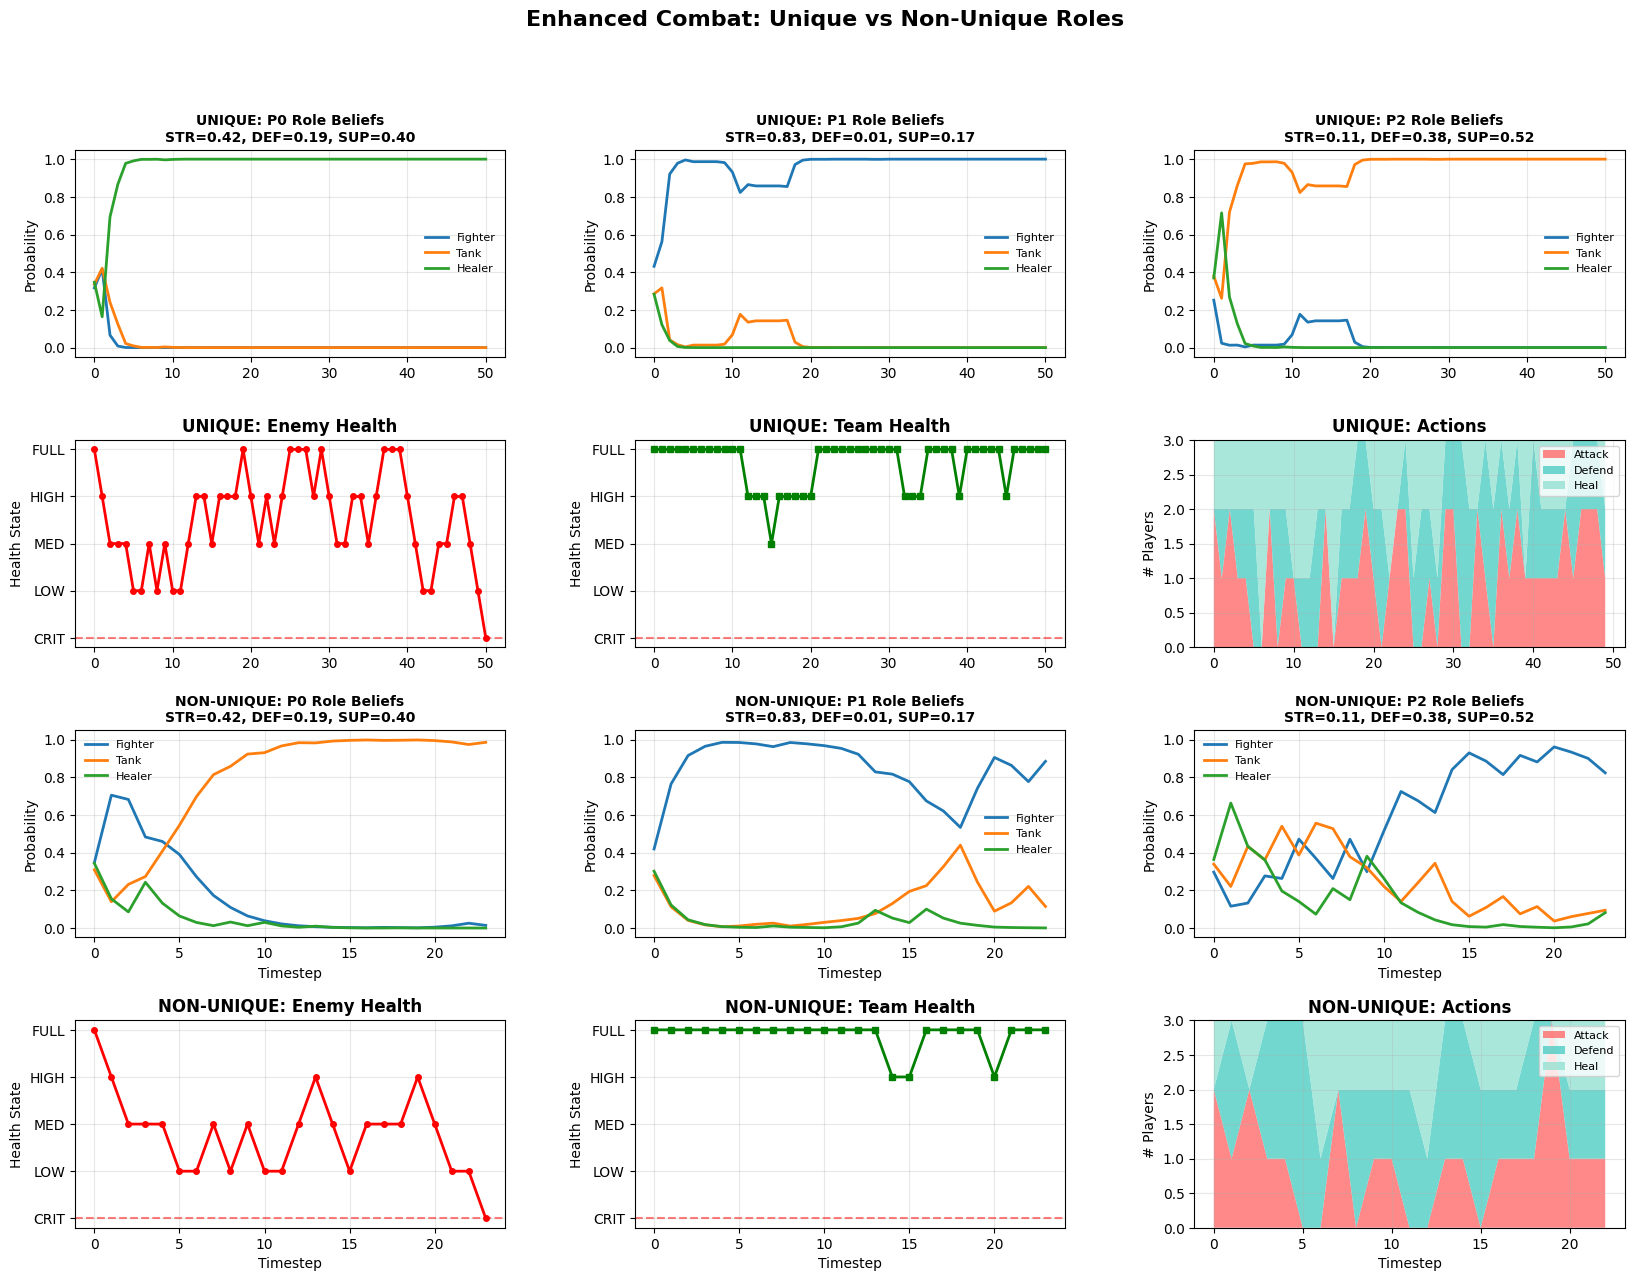


RESULTS SUMMARY

UNIQUE ROLES (Balanced Team):
  Result: WIN
  Duration: 50 steps
  Final Enemy HP: CRITICAL
  Final Team HP: FULL
  Final Roles: P0=Healer, P1=Fighter, P2=Tank
  Total Actions: 52 attacks, 51 defends, 47 heals

NON-UNIQUE ROLES:
  Result: WIN
  Duration: 23 steps
  Final Enemy HP: CRITICAL
  Final Team HP: FULL
  Final Roles: P0=Tank, P1=Fighter, P2=Fighter
  ⚠️ Duplicate roles detected!
  Total Actions: 22 attacks, 30 defends, 17 heals

KEY INSIGHT:
⚖️ Both won, but check team HP and duration:


In [51]:
# ============================================================================
# TEST: Compare "All Fighters" vs "Balanced Team" with new combat system
# ============================================================================

import time

print("\n" + "=" * 80)
print("TESTING ENHANCED COMBAT: All Fighters vs Balanced Team")
print("=" * 80)

# Generate test player stats - random seed each time!
test_seed = int(time.time() * 1000) % 100000
test_stats = [generate_player_stats(i, seed=test_seed) for i in range(3)]

print(f"\nRandom Seed: {test_seed}")
print("\nPlayer Stats:")
for i, stats in enumerate(test_stats):
    print(f"  Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")

print("\n" + "-" * 80)
print("SCENARIO 1: Unique Roles (Balanced Team)")
print("-" * 80)
result_unique = simulate_enhanced_combat(
    n_steps=200,
    player_stats_list=test_stats,
    seed=test_seed,
    temperature=2.0,
    allow_duplicates=False  # Forces Fighter, Tank, Healer
)
role_hist_u, action_hist_u, role_probs_u, enemy_hp_u, team_hp_u, steps_u, status_u, prior_u = result_unique

print("\n" + "-" * 80)
print("SCENARIO 2: Non-Unique Roles (Potentially All Fighters)")
print("-" * 80)
result_nonunique = simulate_enhanced_combat(
    n_steps=200,
    player_stats_list=test_stats,
    seed=test_seed,
    temperature=2.0,
    allow_duplicates=True  # Allows duplicate roles
)
role_hist_nu, action_hist_nu, role_probs_nu, enemy_hp_nu, team_hp_nu, steps_nu, status_nu, prior_nu = result_nonunique

# Visualize comparison with role probabilities
import matplotlib.pyplot as plt
import numpy as onp

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)
fig.suptitle('Enhanced Combat: Unique vs Non-Unique Roles', fontsize=16, fontweight='bold')

# Row 1: Role probabilities for UNIQUE constraint (3 players)
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    player_role_probs = [marginalize(role_probs_u[t], i) for t in range(steps_u)]
    player_role_probs.insert(0, marginalize(prior_u / prior_u.sum(), i))
    player_role_probs = onp.array(player_role_probs)
    
    for role in Role:
        ax.plot(range(steps_u + 1), player_role_probs[:, role], label=role.name, linewidth=2)
    
    stats = test_stats[i]
    ax.set_title(f'UNIQUE: P{i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}', 
                fontsize=10, fontweight='bold')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 2: Health bars for UNIQUE
# Enemy health
ax = fig.add_subplot(gs[1, 0])
ax.plot(range(len(enemy_hp_u)), enemy_hp_u, 'r-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('UNIQUE: Enemy Health', fontweight='bold')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Team health
ax = fig.add_subplot(gs[1, 1])
ax.plot(range(len(team_hp_u)), team_hp_u, 'g-', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('UNIQUE: Team Health', fontweight='bold')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Action distribution
ax = fig.add_subplot(gs[1, 2])
action_counts_u = onp.zeros((steps_u, 3))
for t in range(steps_u):
    for a in action_hist_u[t]:
        action_counts_u[t, int(a)] += 1
ax.stackplot(range(steps_u), 
             action_counts_u[:, 0], action_counts_u[:, 1], action_counts_u[:, 2],
             labels=['Attack', 'Defend', 'Heal'],
             colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
             alpha=0.8)
ax.set_title('UNIQUE: Actions', fontweight='bold')
ax.set_ylabel('# Players')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim([0, 3])
ax.grid(True, alpha=0.3)

# Row 3: Role probabilities for NON-UNIQUE constraint (3 players)
for i in range(3):
    ax = fig.add_subplot(gs[2, i])
    player_role_probs = [marginalize(role_probs_nu[t], i) for t in range(steps_nu)]
    player_role_probs.insert(0, marginalize(prior_nu / prior_nu.sum(), i))
    player_role_probs = onp.array(player_role_probs)
    
    for role in Role:
        ax.plot(range(steps_nu + 1), player_role_probs[:, role], label=role.name, linewidth=2)
    
    stats = test_stats[i]
    ax.set_title(f'NON-UNIQUE: P{i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}', 
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Row 4: Health bars for NON-UNIQUE
# Enemy health
ax = fig.add_subplot(gs[3, 0])
ax.plot(range(len(enemy_hp_nu)), enemy_hp_nu, 'r-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('NON-UNIQUE: Enemy Health', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Team health
ax = fig.add_subplot(gs[3, 1])
ax.plot(range(len(team_hp_nu)), team_hp_nu, 'g-', linewidth=2, marker='s', markersize=4)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('NON-UNIQUE: Team Health', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Health State')
ax.set_yticks(range(5))
ax.set_yticklabels(['CRIT', 'LOW', 'MED', 'HIGH', 'FULL'])
ax.grid(True, alpha=0.3)

# Action distribution
ax = fig.add_subplot(gs[3, 2])
action_counts_nu = onp.zeros((steps_nu, 3))
for t in range(steps_nu):
    for a in action_hist_nu[t]:
        action_counts_nu[t, int(a)] += 1
ax.stackplot(range(steps_nu), 
             action_counts_nu[:, 0], action_counts_nu[:, 1], action_counts_nu[:, 2],
             labels=['Attack', 'Defend', 'Heal'],
             colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
             alpha=0.8)
ax.set_title('NON-UNIQUE: Actions', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('# Players')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim([0, 3])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)
print(f"\nUNIQUE ROLES (Balanced Team):")
print(f"  Result: {status_u}")
print(f"  Duration: {steps_u} steps")
print(f"  Final Enemy HP: {EnemyHealth(int(enemy_hp_u[-1])).name}")
print(f"  Final Team HP: {TeamHealth(int(team_hp_u[-1])).name}")

# Show final roles
unique_final = [Role(onp.argmax(onp.array(marginalize(role_probs_u[-1], i)))).name for i in range(3)]
print(f"  Final Roles: P0={unique_final[0]}, P1={unique_final[1]}, P2={unique_final[2]}")

total_u = onp.sum(action_counts_u, axis=0)
print(f"  Total Actions: {int(total_u[0])} attacks, {int(total_u[1])} defends, {int(total_u[2])} heals")

print(f"\nNON-UNIQUE ROLES:")
print(f"  Result: {status_nu}")
print(f"  Duration: {steps_nu} steps")
print(f"  Final Enemy HP: {EnemyHealth(int(enemy_hp_nu[-1])).name}")
print(f"  Final Team HP: {TeamHealth(int(team_hp_nu[-1])).name}")

# Show final roles and check for duplicates
nonunique_final = [Role(onp.argmax(onp.array(marginalize(role_probs_nu[-1], i)))).name for i in range(3)]
print(f"  Final Roles: P0={nonunique_final[0]}, P1={nonunique_final[1]}, P2={nonunique_final[2]}")

nonunique_has_dups = len(nonunique_final) != len(set(nonunique_final))
if nonunique_has_dups:
    print(f"  ⚠️ Duplicate roles detected!")

total_nu = onp.sum(action_counts_nu, axis=0)
print(f"  Total Actions: {int(total_nu[0])} attacks, {int(total_nu[1])} defends, {int(total_nu[2])} heals")

print("\n" + "=" * 80)
print("KEY INSIGHT:")
if status_u == "WIN" and status_nu == "LOSE":
    print("✅ Balanced team (unique roles) WON, non-unique team LOST!")
    print("   Defense and healing are now CRITICAL for survival!")
elif status_u == "WIN" and status_nu == "WIN":
    print("⚖️ Both won, but check team HP and duration:")
    if team_hp_u[-1] > team_hp_nu[-1]:
        print(f"   Balanced team finished healthier ({TeamHealth(int(team_hp_u[-1])).name} vs {TeamHealth(int(team_hp_nu[-1])).name})")
    if steps_u < steps_nu:
        print(f"   Balanced team won faster ({steps_u} vs {steps_nu} steps)")
elif status_u == "LOSE" and status_nu == "WIN":
    print("⚠️ Non-unique team won, balanced team lost!")
    print("   This is unexpected - check the role distributions!")
else:
    print(f"   Unique: {status_u}, Non-unique: {status_nu}")
print("=" * 80)